In [1]:
import torch
import torchvision
from torchvision import transforms as T
from PIL import Image
import cv2
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchvision.models.detection import mask_rcnn, faster_rcnn
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
import torch.nn as nn

In [301]:
# load a pre-trained model for classification and return
# only the features
resnet_net = torchvision.models.resnet101(pretrained=True)
modules = list(resnet_net.children())[:-1]
backbone = nn.Sequential(*modules)
# FasterRCNN needs to know the number of
# output channels in a backbone. For mobilenet_v2, it's 1280
# so we need to add it here
backbone.out_channels = 2048

# let's make the RPN generate 5 x 3 anchors per spatial
# location, with 5 different sizes and 3 different aspect
# ratios. We have a Tuple[Tuple[int]] because each feature
# map could potentially have different sizes and
# aspect ratios
anchor_boxes = [64, 64, 
                48, 128, 
                64, 192, 
                96, 256, 
                128, 352, 
                128, 128, 
                192, 512, 
                256, 704, 
                352, 832, 
                256, 256, 
                512, 512, 
                192, 832]
anchor_generator = AnchorGenerator(
        sizes=(anchor_boxes[0::2],)
    )

# let's define what are the feature maps that we will
# use to perform the region of interest cropping, as well as
# the size of the crop after rescaling.
# if your backbone returns a Tensor, featmap_names is expected to
# be [0]. More generally, the backbone should return an
# OrderedDict[Tensor], and in featmap_names you can choose which
# feature maps to use.
roi_pooler = torchvision.ops.MultiScaleRoIAlign(featmap_names=['0'],
                                                output_size=(8,7),
                                                sampling_ratio=2)

# put the pieces together inside a FasterRCNN model
model = FasterRCNN(backbone,
                   num_classes=2,
                   rpn_anchor_generator=anchor_generator,
                   box_roi_pool=roi_pooler)

In [ ]:
class ImageDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.image_filenames = os.listdir(img_dir)

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        image_path = os.path.join(self.img_dir, self.image_filenames[idx])
        image = Image.open(image_path)
        if self.transform:
            image = self.transform(image)
        return image

In [6]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn()

In [7]:
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu

In [316]:
ig = Image.open('meter2.jpg')

In [317]:
transform = T.ToTensor()
img = transform(ig)

In [291]:
img.shape

torch.Size([3, 480, 640])

In [318]:
with torch.no_grad():
    prediction = model([img])

In [319]:
bboxes, labels, scores = prediction[0]['boxes'], prediction[0]['labels'], prediction[0]['scores']

In [320]:
num = torch.argwhere(scores > 0).shape[0]
num

13

In [321]:
scores

tensor([0.2502, 0.2259, 0.2037, 0.1703, 0.1458, 0.1014, 0.0873, 0.0843, 0.0833,
        0.0826, 0.0736, 0.0689, 0.0536])

In [322]:
igg = cv2.imread('meter2.jpg')
for i in range(num):
    x1, y1, x2, y2 = bboxes[5].numpy().astype(int)
   
    igg = cv2.rectangle(igg, (x1, y1), (x2, y2), (255, 0, 0), 2)

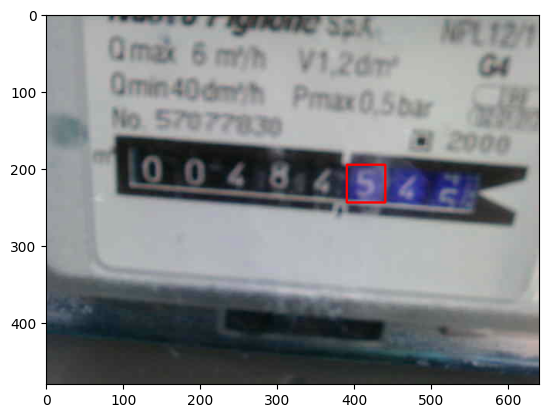

In [323]:
from matplotlib import pyplot as plt
plt.imshow(igg)
plt.show()